In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


In [2]:
df = pd.read_parquet("d:/FIAP/Engenharia de Machine Learning/Fase 3/tech_challenge_3/data/processed/flights_processed.parquet")

In [3]:
pd.set_option('display.max_columns', None) 
df.head()

,AIRLINE,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,AIRPORT,CITY,STATE,LATITUDE,LONGITUDE,DATE,HOUR,IS_DELAYED,IS_SHORT_DISTANCE,IS_MEDIUM_DISTANCE,IS_LONG_DISTANCE,IS_MORNING,IS_AFTERNOON,IS_NIGHT,IS_HOLIDAY,IS_WINTER,IS_SPRING,IS_SUMMER,IS_FALL
0,AS,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,-11.0,205.0,1448,430,Ted Stevens Anchorage International Airport,Anchorage,AK,61.17432,-149.99619,2015-01-01,0,0,0,1,0,1,0,0,1,1,0,0,0
1,AA,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,-8.0,280.0,2330,750,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,2015-01-01,0,0,0,0,1,1,0,0,1,1,0,0,0
2,US,2015,1,1,4,US,840,N171US,SFO,CLT,20,-2.0,286.0,2296,806,San Francisco International Airport,San Francisco,CA,37.61900,-122.37484,2015-01-01,0,0,0,0,1,1,0,0,1,1,0,0,0
3,AA,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,-5.0,285.0,2342,805,Los Angeles International Airport,Los Angeles,CA,33.94254,-118.40807,2015-01-01,0,0,0,0,1,1,0,0,1,1,0,0,0
4,AS,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,-1.0,235.0,1448,320,Seattle-Tacoma International Airport,Seattle,WA,47.44898,-122.30931,2015-01-01,0,0,0,1,0,1,0,0,1,1,0,0,0


In [4]:
# Filtrar voos atrasados
delayed_flights_origin = df[df["IS_DELAYED"] == 1]

# Contar atrasos por aeroporto de origem
delays_by_airport_origin = delayed_flights_origin["ORIGIN_AIRPORT"].value_counts()

# Proporção em relação ao total de atrasos
delays_by_airport_origin_percent = delays_by_airport_origin / delays_by_airport_origin.sum() * 100

top10_airports = delays_by_airport_origin_percent.head(10).index  # Top 10 aeroportos

# Criar coluna nova
df["ORIGIN_AIRPORT_TOP10"] = df["ORIGIN_AIRPORT"].where(df["ORIGIN_AIRPORT"].isin(top10_airports), "Other")

In [5]:
# Filtrar voos atrasados
delayed_flights_destination = df[df["IS_DELAYED"] == 1]

# Contar atrasos por aeroporto de origem
delays_by_airport_destination = delayed_flights_destination["DESTINATION_AIRPORT"].value_counts()

# Proporção em relação ao total de atrasos
delays_by_airport_percent = delays_by_airport_destination / delays_by_airport_destination.sum() * 100

top10_airports_dest = delays_by_airport_percent.head(10).index  # Top 10 aeroportos

# Converter para string
df["DESTINATION_AIRPORT"] = df["DESTINATION_AIRPORT"].astype(str)

# Criar coluna Top10 + Other
df["DESTINATION_AIRPORT_TOP10"] = df["DESTINATION_AIRPORT"].where(df["DESTINATION_AIRPORT"].isin(top10_airports_dest), "Other")

In [6]:
# Filtrar voos atrasados
delayed_flights = df[df["IS_DELAYED"] == 1]

# Contar atrasos por aeroporto de origem
delays_by_airport = delayed_flights["CITY"].value_counts()

# Proporção em relação ao total de atrasos
delays_by_airport_percent = delays_by_airport / delays_by_airport.sum() * 100

top10_airports = delays_by_airport_percent.head(10).index  # Top 10 aeroportos

# Converter para string
df["CITY"] = df["CITY"].astype(str)

# Criar coluna Top10 + Other
df["CITY_TOP10"] = df["CITY"].where(df["CITY"].isin(top10_airports), "Other")

In [7]:
# Filtrar voos atrasados
delayed_flights = df[df["IS_DELAYED"] == 1]

# Contar atrasos por aeroporto de origem
delays_by_airport = delayed_flights["STATE"].value_counts()

# Proporção em relação ao total de atrasos
delays_by_airport_percent = delays_by_airport / delays_by_airport.sum() * 100

top10_airports = delays_by_airport_percent.head(10).index  # Top 10 aeroportos

# Converter para string
df["STATE"] = df["STATE"].astype(str)

# Criar coluna Top10 + Other
df["STATE_TOP10"] = df["STATE"].where(df["STATE"].isin(top10_airports), "Other")

In [8]:
# Filtrar voos atrasados
delayed_flights = df[df["IS_DELAYED"] == 1]

# Contar atrasos por aeroporto de origem
delays_by_airport = delayed_flights["TAIL_NUMBER"].value_counts()

# Proporção em relação ao total de atrasos
delays_by_airport_percent = delays_by_airport / delays_by_airport.sum() * 100

top10_airports = delays_by_airport_percent.head(10).index  # Top 10 aeroportos

# Converter para string
df["TAIL_NUMBER"] = df["TAIL_NUMBER"].astype(str)

# Criar coluna Top10 + Other
df["TAIL_NUMBER_TOP10"] = df["TAIL_NUMBER"].where(df["TAIL_NUMBER"].isin(top10_airports), "Other")

In [12]:
sample_df = df.sample(frac=0.1, random_state=42)

In [14]:
sample_df.shape

(522657, 39)

## Tentativa 1: randomforest

In [15]:
#separa features e target 
X = sample_df.drop(columns=["IS_DELAYED", "DEPARTURE_DELAY", "DATE", "YEAR", "DAY", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE", "AIRPORT", "CITY", "STATE", "TAIL_NUMBER"])  # remove target e colunas que “vazam” info
y = sample_df["IS_DELAYED"]

In [16]:
X.head()

,MONTH,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,LATITUDE,LONGITUDE,HOUR,IS_SHORT_DISTANCE,IS_MEDIUM_DISTANCE,IS_LONG_DISTANCE,IS_MORNING,IS_AFTERNOON,IS_NIGHT,IS_HOLIDAY,IS_WINTER,IS_SPRING,IS_SUMMER,IS_FALL,ORIGIN_AIRPORT_TOP10,DESTINATION_AIRPORT_TOP10,CITY_TOP10,STATE_TOP10,TAIL_NUMBER_TOP10
182179,1,2,DL,2113,819,196.0,986,1035,42.21206,-83.34884,8,0,1,0,1,0,0,0,1,0,0,0,Other,DFW,Other,Other,Other
628526,2,4,B6,1472,2015,165.0,1076,2300,26.07258,-80.15275,20,0,1,0,0,0,1,0,1,0,0,0,Other,Other,Other,FL,Other
3206122,7,5,DL,2385,1520,145.0,926,1645,42.21206,-83.34884,15,0,1,0,0,1,0,0,0,0,1,0,Other,Other,Other,Other,Other
2101603,5,7,UA,741,1935,277.0,1846,2212,41.97960,-87.90446,19,0,0,1,0,0,1,0,0,1,0,0,ORD,SFO,Chicago,IL,Other
4324892,11,1,DL,2161,1930,142.0,666,2152,39.87195,-75.24114,19,0,1,0,0,0,1,0,0,0,0,1,Other,ATL,Other,Other,Other


In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [18]:
for col in ["AIRLINE_CODE", "ORIGIN_AIRPORT_TOP10", "DESTINATION_AIRPORT_TOP10", "CITY_TOP10", "STATE_TOP10", "TAIL_NUMBER_TOP10"]:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [19]:
# Criar o modelo
model = RandomForestClassifier(
    n_estimators=100,        # número de árvores
    random_state=42,
    class_weight="balanced"  # importante em targets desbalanceados
)

# Treinar
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # probabilidade de atraso 

In [23]:
y_pred[:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0], dtype=int8)

In [21]:
# Relatório completo
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.82      0.92      0.87    127004
           1       0.33      0.17      0.22     29794

    accuracy                           0.78    156798
   macro avg       0.58      0.54      0.55    156798
weighted avg       0.73      0.78      0.75    156798

[[117032   9972]
 [ 24861   4933]]
ROC-AUC: 0.6392206245993732


✅ Muito bom para classe 0
❌ Muito ruim para classe 1

Ou seja:

ele quase não detecta a classe minoritária.

## Tentativa 2: Balancear dataset

In [25]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

In [27]:
from collections import Counter

print(Counter(y))
print(Counter(y_res))

Counter({0: 423343, 1: 99314})
Counter({0: 99314, 1: 99314})


In [29]:
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res)

In [30]:
for col in ["AIRLINE_CODE", "ORIGIN_AIRPORT_TOP10", "DESTINATION_AIRPORT_TOP10", "CITY_TOP10", "STATE_TOP10", "TAIL_NUMBER_TOP10"]:
    le = LabelEncoder()
    X_train_res[col] = le.fit_transform(X_train_res[col])
    X_test_res[col] = le.transform(X_test_res[col])

In [31]:
# Criar o modelo
model = RandomForestClassifier(
    n_estimators=100,        # número de árvores
    random_state=42,
    class_weight="balanced"  # importante em targets desbalanceados
)

# Treinar
model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # probabilidade de atraso 

In [33]:
# Relatório completo
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.95      0.61      0.74    127004
           1       0.34      0.87      0.49     29794

    accuracy                           0.66    156798
   macro avg       0.65      0.74      0.62    156798
weighted avg       0.84      0.66      0.69    156798

[[76861 50143]
 [ 3817 25977]]
ROC-AUC: 0.8486171457929841


Detectou 25977 casos da classe 1
Perdeu apenas 3817

recall alto para classe 1
precision baixo -- Ele detecta quase todos, mas gera muitos falsos positivos.

In [34]:
feat_imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feat_imp.head(20))

DAY_OF_WEEK                  0.117043
SCHEDULED_ARRIVAL            0.110491
SCHEDULED_DEPARTURE          0.108292
FLIGHT_NUMBER                0.103658
SCHEDULED_TIME               0.092080
DISTANCE                     0.082278
MONTH                        0.074717
LONGITUDE                    0.047306
LATITUDE                     0.046667
HOUR                         0.037977
AIRLINE_CODE                 0.035800
DESTINATION_AIRPORT_TOP10    0.027479
STATE_TOP10                  0.018072
CITY_TOP10                   0.013415
ORIGIN_AIRPORT_TOP10         0.011930
IS_SPRING                    0.010059
IS_SUMMER                    0.009656
IS_MORNING                   0.009153
IS_WINTER                    0.008991
IS_HOLIDAY                   0.006218
dtype: float64


## Tentativa 3: ajustar hiperparametros

In [36]:
# pega probabilidade da classe 1
y_prob = model.predict_proba(X_test_res)[:, 1]
threshold = 0.6  # O threshold (ou limiar) define a partir de qual probabilidade o modelo decide que a previsão é “classe 1”.
y_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test_res, y_pred))
print(confusion_matrix(y_test_res, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_res, y_prob))

              precision    recall  f1-score   support

           0       0.58      0.73      0.64     29795
           1       0.63      0.47      0.54     29794

    accuracy                           0.60     59589
   macro avg       0.60      0.60      0.59     59589
weighted avg       0.60      0.60      0.59     59589

[[21605  8190]
 [15792 14002]]
ROC-AUC: 0.6439783808092855


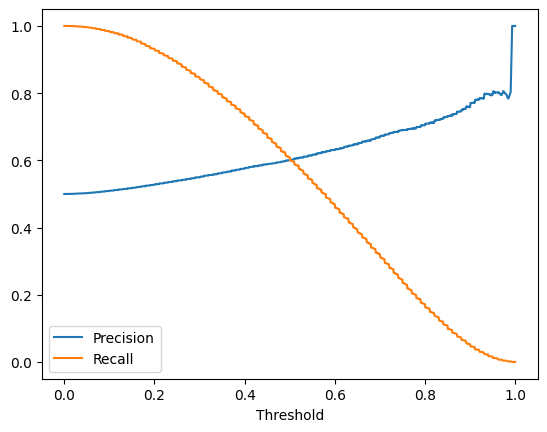

In [38]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test_res, y_prob)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()

## Tentativa 4

In [46]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score

# Ajustando para desbalanceamento
scale = sum(y_train_res==0) / sum(y_train_res==1)  # razão de classes
model = xgb.XGBClassifier(
    scale_pos_weight=scale,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

# Treinar
model.fit(X_train_res, y_train_res)

# Previsão
y_prob = model.predict_proba(X_test_res)[:,1]

# Ajustando threshold manual ou usando PR curve depois
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Avaliar
print(classification_report(y_test_res, y_pred))
print("ROC-AUC:", roc_auc_score(y_test_res, y_prob))

c:\Users\alice\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:30:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.64      0.62      0.63     29795
           1       0.63      0.65      0.64     29794

    accuracy                           0.64     59589
   macro avg       0.64      0.64      0.64     59589
weighted avg       0.64      0.64      0.64     59589

ROC-AUC: 0.6863939004197339


In [47]:
#separa features e target 
X = df.drop(columns=["IS_DELAYED", "DEPARTURE_DELAY", "DATE", "YEAR", "DAY", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "AIRLINE", "AIRPORT", "CITY", "STATE", "TAIL_NUMBER"])  # remove target e colunas que “vazam” info
y = df["IS_DELAYED"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

for col in ["AIRLINE_CODE", "ORIGIN_AIRPORT_TOP10", "DESTINATION_AIRPORT_TOP10", "CITY_TOP10", "STATE_TOP10", "TAIL_NUMBER_TOP10"]:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [49]:
# Ajustando para desbalanceamento
scale = sum(y_train==0) / sum(y_train==1)  # razão de classes
model = xgb.XGBClassifier(
    scale_pos_weight=scale,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

# Treinar
model.fit(X_train, y_train)

# Previsão
y_prob = model.predict_proba(X_test)[:,1]

# Ajustando threshold manual ou usando PR curve depois
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# Avaliar
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

c:\Users\alice\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:35:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.89      0.64      0.74   1271054
           1       0.30      0.66      0.41    296917

    accuracy                           0.64   1567971
   macro avg       0.60      0.65      0.58   1567971
weighted avg       0.78      0.64      0.68   1567971

ROC-AUC: 0.7106316043299934


In [53]:
X_train.head()

,MONTH,DAY_OF_WEEK,AIRLINE_CODE,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,LATITUDE,LONGITUDE,HOUR,IS_SHORT_DISTANCE,IS_MEDIUM_DISTANCE,IS_LONG_DISTANCE,IS_MORNING,IS_AFTERNOON,IS_NIGHT,IS_HOLIDAY,IS_WINTER,IS_SPRING,IS_SUMMER,IS_FALL,ORIGIN_AIRPORT_TOP10,DESTINATION_AIRPORT_TOP10,CITY_TOP10,STATE_TOP10,TAIL_NUMBER_TOP10
928719,3,4,11,2069,1200,121.0,541,1401,40.63975,-73.77893,12,0,1,0,0,1,0,0,1,0,0,0,8,8,7,8,10
4357173,11,3,0,134,1955,398.0,2724,2333,25.79325,-80.29056,19,0,0,1,0,0,1,0,0,0,0,1,8,8,8,3,10
3499685,8,2,0,1905,925,94.0,468,1059,35.21401,-80.94313,9,1,0,0,1,0,0,0,0,0,1,0,8,8,8,6,10
1243093,3,3,4,5987,616,109.0,475,705,35.81249,-83.99286,6,1,0,0,1,0,0,0,0,1,0,0,8,7,8,9,10
3469359,8,7,3,1761,1242,127.0,666,1449,33.64044,-84.42694,12,0,1,0,0,1,0,0,0,0,1,0,0,8,0,4,10


In [ ]:
from sklearn.preprocessing import StandardScaler

# Lista das features contínuas que precisam de normalização
continuous_features = [
    "MONTH", "DAY_OF_WEEK", "AIRLINE_CODE", "FLIGHT_NUMBER","SCHEDULED_DEPARTURE","SCHEDULED_TIME", "DISTANCE", "SCHEDULED_ARRIVAL", "HOUR"
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

In [ ]:
# Features que têm maior impacto
important_features = [
    "DAY_OF_WEEK",
    "SCHEDULED_ARRIVAL",
    "SCHEDULED_DEPARTURE",
    "FLIGHT_NUMBER",
    "SCHEDULED_TIME",
    "DISTANCE",
    "HOUR",
    "AIRLINE_CODE",
    "DESTINATION_AIRPORT_TOP10",
    "STATE_TOP10",
    "CITY_TOP10",
    "ORIGIN_AIRPORT_TOP10"
]

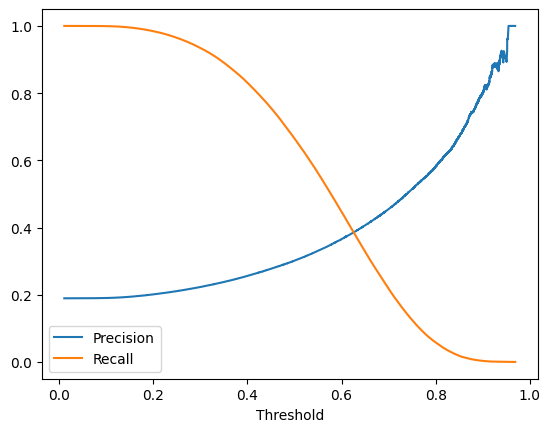

In [51]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.show()